# Ejemplo Maquinas de Soporte Vectorial
## 1) IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score


## 2) GENERAR DATASET

In [2]:
def generar_dataset(n_samples=300, factor=0.4, noise=0.15, random_state=42):
    X, y = make_circles(n_samples=n_samples, factor=factor, noise=noise, random_state=random_state)
    return X, y

# Ejecutar: generar datos y mostrarlos en variables globales
X, y = generar_dataset()
print("Dataset generado. X.shape:", X.shape, "y.shape:", y.shape)

Dataset generado. X.shape: (300, 2) y.shape: (300,)


## 3) VISUALIZAR EN 2D

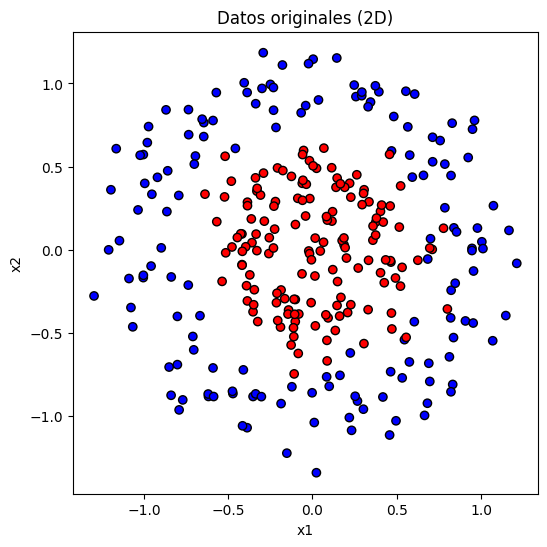

In [3]:
def plot_2d(X, y, title="Dataset 2D - make_circles"):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(X[:,0], X[:,1], c=y, cmap="bwr", edgecolor='k')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(title)
    plt.show()

# Ejecutar: ver los datos 2D
plot_2d(X, y, title="Datos originales (2D)")

# 4) ENTRENAR SVM LINEAL

In [4]:
def entrenar_svm_lineal_2d(X_train, y_train, C=1.0):
    pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='linear', C=C))])
    pipe.fit(X_train, y_train)
    return pipe

# Preparar split (globalmente visible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print("Train/Test split listo. Train:", X_train.shape[0], " Test:", X_test.shape[0])

Train/Test split listo. Train: 210  Test: 90


# 5) DIBUJAR FRONTERA DE DECISIÓN EN 2D

Accuracy SVM lineal (2D, test): 0.43333333333333335


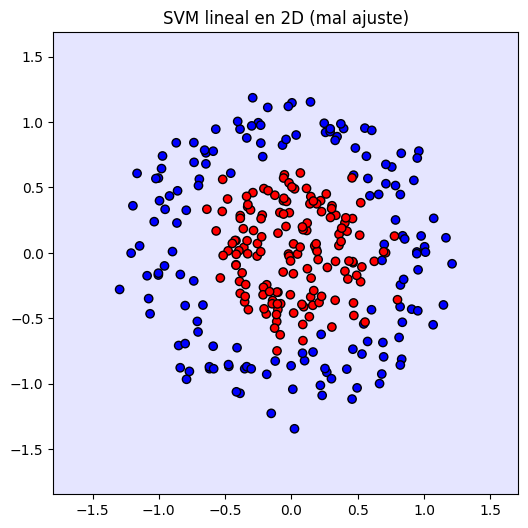

In [5]:
def plot_decision_boundary_2d(model, X, y, title='Frontera de decisión (2D)'):
    fig, ax = plt.subplots(figsize=(6,6))
    x_min, x_max = X[:,0].min() - .5, X[:,0].max() + .5
    y_min, y_max = X[:,1].min() - .5, X[:,1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, levels=[-1,0,1], cmap='bwr')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
    ax.set_title(title)
    plt.show()

# Ejecutar: entrenar SVM lineal y mostrar frontera
modelo_lineal_2d = entrenar_svm_lineal_2d(X_train, y_train, C=1.0)
y_pred_lin2 = modelo_lineal_2d.predict(X_test)
print("Accuracy SVM lineal (2D, test):", accuracy_score(y_test, y_pred_lin2))
plot_decision_boundary_2d(modelo_lineal_2d, X, y, title="SVM lineal en 2D (mal ajuste)")

# 6) ENTRENAR SVM RBF EN 2D

Accuracy SVM RBF (2D, test): 0.9666666666666667


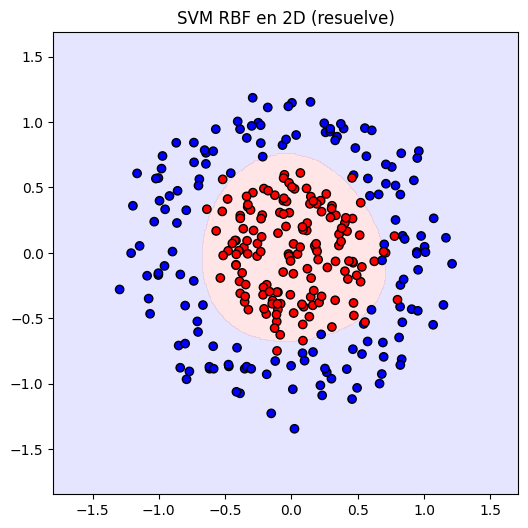

In [6]:
def entrenar_svm_rbf_2d(X_train, y_train, C=1.0, gamma='scale'):
    pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf', C=C, gamma=gamma))])
    pipe.fit(X_train, y_train)
    return pipe

# Ejecutar: entrenar y mostrar frontera RBF
modelo_rbf_2d = entrenar_svm_rbf_2d(X_train, y_train, C=1.0)
y_pred_rbf2 = modelo_rbf_2d.predict(X_test)
print("Accuracy SVM RBF (2D, test):", accuracy_score(y_test, y_pred_rbf2))
plot_decision_boundary_2d(modelo_rbf_2d, X, y, title="SVM RBF en 2D (resuelve)")


# 7) MAPEADO A 3D (feature map manual): z = x1^2 + x2^2

In [7]:
def feature_map_3d(X):
    x1 = X[:,0]; x2 = X[:,1]
    z = x1**2 + x2**2
    return np.column_stack([x1, x2, z])

# Ejecutar: mapear datos
X3 = feature_map_3d(X)
print("X3 shape:", X3.shape)


X3 shape: (300, 3)


# 8) VISUALIZAR EN 3D

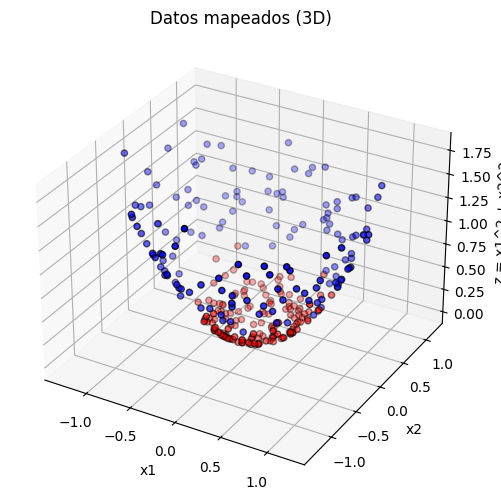

In [8]:
def plot_3d_points(X3, y, title='Datos mapeados a 3D'):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X3[:,0], X3[:,1], X3[:,2], c=y, cmap='bwr', edgecolor='k')
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('z = x1^2 + x2^2')
    ax.set_title(title)
    plt.show()

# Ejecutar: ver puntos en 3D
plot_3d_points(X3, y, title="Datos mapeados (3D)")


# 9) ENTRENAR SVM LINEAL EN 3D

In [9]:
def entrenar_svm_lineal_3d(X3_train, y_train, C=1.0):
    pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='linear', C=C))])
    pipe.fit(X3_train, y_train)
    return pipe

# Ejecutar: split y entrenamiento en 3D
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.3, random_state=0)
modelo_lineal_3d = entrenar_svm_lineal_3d(X3_train, y3_train, C=1.0)
y3_pred = modelo_lineal_3d.predict(X3_test)
print("Accuracy SVM lineal (3D, test):", accuracy_score(y3_test, y3_pred))

Accuracy SVM lineal (3D, test): 0.9666666666666667


# 10) DIBUJAR HIPERPLANO EN 3D

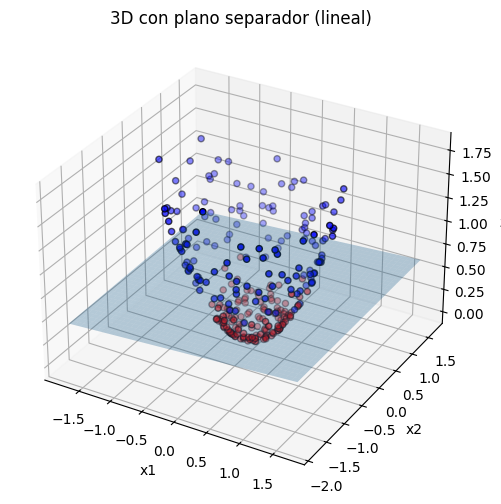

In [10]:
def plot_3d_with_plane(X3, y, svm_pipeline, title='3D con hiperplano separador'):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X3[:,0], X3[:,1], X3[:,2], c=y, cmap='bwr', edgecolor='k')
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('z')
    ax.set_title(title)

    # Extraer scaler y clasificador lineal
    scaler = svm_pipeline.named_steps['scaler']
    clf = svm_pipeline.named_steps['svm']

    if not hasattr(clf, 'coef_'):
        raise ValueError("El clasificador debe ser lineal y tener coef_")

    w = clf.coef_[0]
    b = clf.intercept_[0]

    # Crear malla en x-y original
    x_min, x_max = X3[:,0].min() - .5, X3[:,0].max() + .5
    y_min, y_max = X3[:,1].min() - .5, X3[:,1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 40), np.linspace(y_min, y_max, 40))

    # Construir grid con la z original (z = x^2 + y^2)
    grid_orig = np.c_[xx.ravel(), yy.ravel(), (xx.ravel()**2 + yy.ravel()**2)]
    grid_scaled = scaler.transform(grid_orig)

    x_s = grid_scaled[:,0]; y_s = grid_scaled[:,1]
    # Evita división por cero
    if abs(w[2]) < 1e-8:
        print("w[2] cercano a 0 — no se puede resolver z_s directamente")
        return
    z_s = (-w[0]*x_s - w[1]*y_s - b) / w[2]

    # Volver a escala original la z
    z_orig = z_s * scaler.scale_[2] + scaler.mean_[2]
    Z = z_orig.reshape(xx.shape)

    ax.plot_surface(xx, yy, Z, alpha=0.3)
    plt.show()

# Ejecutar: graficar hiperplano en 3D
plot_3d_with_plane(X3, y, modelo_lineal_3d, title="3D con plano separador (lineal)")

# 11) BÚSQUEDA DEL C ÓPTIMO (soft-margin) EN 3D

In [11]:

def buscar_C_optimo(X, y, kernel='linear', Cs=np.logspace(-3,3,13), cv=5):
    pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel=kernel))])
    param_grid = {'svm__C': Cs}
    gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    gs.fit(X, y)
    return gs

# Ejecutar: buscar C en espacio 3D
Cs = np.logspace(-3, 3, 13)
gs_3d = buscar_C_optimo(X3, y, kernel='linear', Cs=Cs)
print("Mejor C (3D linear):", gs_3d.best_params_)
print("Mejor score (CV):", gs_3d.best_score_)

Mejor C (3D linear): {'svm__C': 0.31622776601683794}
Mejor score (CV): 0.97


# 12) GRAFICA: performance vs C

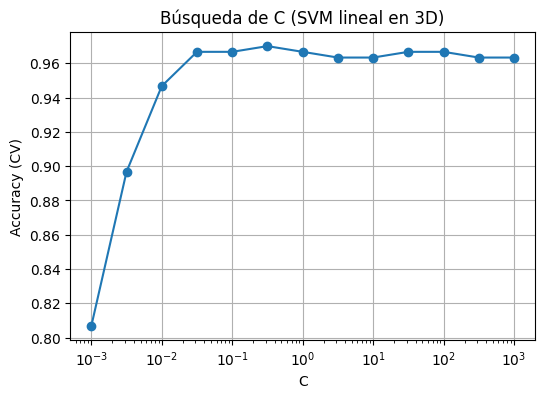

In [12]:
plt.figure(figsize=(6,4))
plt.semilogx(Cs, gs_3d.cv_results_['mean_test_score'], marker='o')
plt.xlabel('C'); plt.ylabel('Accuracy (CV)')
plt.title('Búsqueda de C (SVM lineal en 3D)')
plt.grid(True)
plt.show()

# 13) OPCIONAL: comparar búsqueda C en 2D (RBF) — muestra cómo kernels vs mapeo afectan la elección de C

Mejor C (2D RBF): {'svm__C': 31.622776601683793} Score CV: 0.97


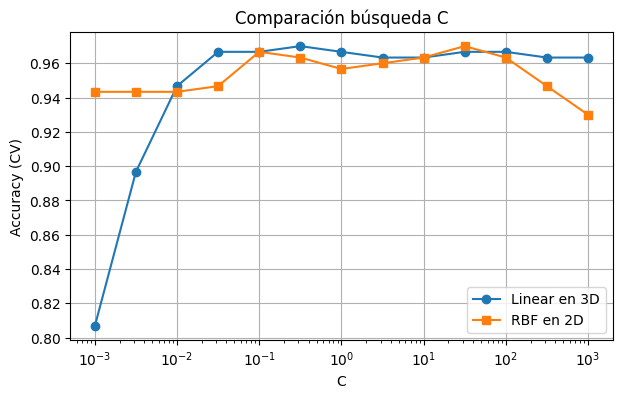

In [13]:
gs_rbf_2d = buscar_C_optimo(X, y, kernel='rbf', Cs=Cs)
print("Mejor C (2D RBF):", gs_rbf_2d.best_params_, "Score CV:", gs_rbf_2d.best_score_)

plt.figure(figsize=(7,4))
plt.semilogx(Cs, gs_3d.cv_results_['mean_test_score'], marker='o', label='Linear en 3D')
plt.semilogx(Cs, gs_rbf_2d.cv_results_['mean_test_score'], marker='s', label='RBF en 2D')
plt.xlabel('C'); plt.ylabel('Accuracy (CV)'); plt.title('Comparación búsqueda C')
plt.legend(); plt.grid(True); plt.show()
